# Siddak Marwaha
# CMSE 381 HW5

### Subset selection problem

a) Best Subset Selection
-	Steps:
1.	For k = 0,1,2,3,4, evaluate all possible subsets of variables (cylinders, horsepower, weight, acceleration).
2.	Fit each model on the training set.
3.	Evaluate performance using training and testing scores.
4.	Choose the best model based on the lowest testing error.

-	Models evaluated (best Mk for each k):
    - M0: Null model (no variables)
Test score: 60.73
    - M1: Best one-variable model: weight
Test score: 18.84
    - M2: Best two-variable model: horsepower, weight
Test score: 18.03
    - M3: Best three-variable model: cylinders, horsepower, weight
Test score: 17.99
    - M4: Best four-variable model: cylinders, horsepower, weight, acceleration
Test score: 18.13

Best model: M3 with cylinders, horsepower, weight.

-	Equation:
mpg = β0 + β1 * cylinders + β2 * horsepower + β3 * weight

-	To evaluate all possible models:
    - For k = 0, 1 model (null).
    - For k = 1, 4 models (one for each variable).
    - For k = 2, (4 2) = 6 models
    - For k = 3, (4 3) = 4 models
    - For k = 4, 1 model (all).

Total = 16 models.

b) Forward Selection
- Steps:
1.	Start with no predictors.
2.	Add the predictor that minimizes the test error at each step.
3.	Repeat until adding more predictors doesn't improve the model.

-	Models evaluated:
    - Start with no predictors M0: Null model (Test = 60.73).
    - Step 1: Add weight (best single predictor). M1 with weight (Test = 18.84).
    - Step 2: Add horsepower. M2 with horsepower, weight (Test = 18.03).
    - Step 3: Add cylinders. M3 with cylinders, horsepower, weight (Test = 17.99).
    - Stop: Adding acceleration doesn't improve the test score significantly.

Best model: M3 with cylinders, horsepower, weight

- Equation:
mpg = β0 + β1 * cylinders + β2 * horsepower + β3 * weight

- How many models trained?
    - M0 (null), M1 (1 variable), M2 (2 variables), and M3 (3 variables).

Total = 4 models.

c) Backward Selection
- Steps for Backward Selection:
1.	Start with the full model (all predictors).
2.	Remove the predictor that minimizes the test error at each step.
3.	Repeat until removing more predictors doesn't improve the model.

-	Steps and selected models:
•	Start with all predictors M4: Full model with cylinders, horsepower, weight, acceleration (Test = 18.13).
•	Step 1: Remove acceleration. M3 with cylinders, horsepower, weight (Test = 17.99).
•	Step 2: No further removal improves the model significantly, so stop here.

Best model: M3 with cylinders, horsepower, weight

- Equation:
mpg = β0 + β1 * cylinders + β2 * horsepower + β3 * weight 

- How many models trained?
    - M4 (full model), and M3 (after removing acceleration).

Total = 2 models.

d) Yes, the best models returned by all three methods are the same. In each case, the best model is M3, which includes cylinders, horsepower, and weight. This is because all three methods aim to minimize the test error, and the data clearly shows that this combination of variables produces the lowest test error.

Do we expect them to be the same? 
Not always. The methods use different approaches. However, in this particular case, the best model happens to be the same for all three methods. In general, best subset selection considers all possible models and is guaranteed to find the optimal model, while forward selection and backward selection can sometimes find sub-par models depending on the data. But here, all methods agree on the same model.


### Q 6.6.9

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a)

In [2]:
college = pd.read_csv('College.csv')

In [3]:
college = college.drop(columns=['Unnamed: 0'])

# Convert categorical variable 'Private' to binary
college['Private'] = college['Private'].map({'Yes': 1, 'No': 0})

# Split
X = college.drop(columns=['Apps'])
y = college['Apps']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# Standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


b)

In [6]:
# Fit
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict and calculate test error
y_pred_linear = linear_model.predict(X_test)
test_error_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Test Error (Linear Regression): {test_error_linear}")


Test Error (Linear Regression): 1931803.1942070178


c)

Test Error (Ridge Regression): 1928464.059895412


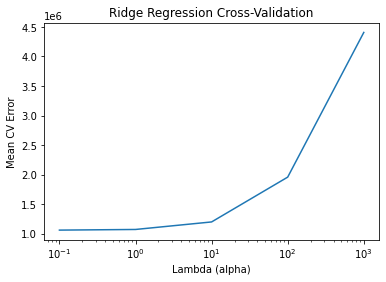

In [7]:
# Fit the ridge model with cross-validation
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_model = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_model.fit(X_train, y_train)

# Predict and calculate test error
y_pred_ridge = ridge_model.predict(X_test)
test_error_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Test Error (Ridge Regression): {test_error_ridge}")

# Plot test error vs lambda values
plt.plot(alphas, ridge_model.cv_values_.mean(axis=0), label="Cross-Validation Error")
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Mean CV Error')
plt.title('Ridge Regression Cross-Validation')
plt.show()


d)

Test Error (Lasso Regression): 1927762.1567389034
Number of Non-Zero Coefficients: 17


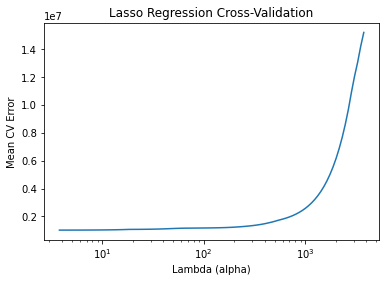

In [8]:
# Fit the lasso model with cross-validation
lasso_model = LassoCV(cv=10).fit(X_train, y_train)

# Predict and calculate test error
y_pred_lasso = lasso_model.predict(X_test)
test_error_lasso = mean_squared_error(y_test, y_pred_lasso)
num_nonzero_coefs = np.sum(lasso_model.coef_ != 0)

print(f"Test Error (Lasso Regression): {test_error_lasso}")
print(f"Number of Non-Zero Coefficients: {num_nonzero_coefs}")

# Plot test error vs lambda values
plt.plot(lasso_model.alphas_, np.mean(lasso_model.mse_path_, axis=1), label="Cross-Validation Error")
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Mean CV Error')
plt.title('Lasso Regression Cross-Validation')
plt.show()


e)

Best M (Number of Components): 16
Test Error (PCR): 1871781.308411684


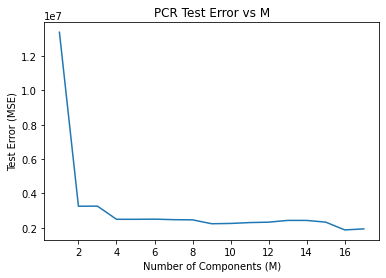

In [9]:
# Try different numbers of M for PCR
m_values = range(1, X_train.shape[1] + 1)
mse_values = []

for m in m_values:
    pca = PCA(n_components=m)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    
    y_pred_pca = model.predict(X_test_pca)
    mse = mean_squared_error(y_test, y_pred_pca)
    mse_values.append(mse)

best_m = m_values[np.argmin(mse_values)]
print(f"Best M (Number of Components): {best_m}")
print(f"Test Error (PCR): {min(mse_values)}")

# Plot test error vs M values
plt.plot(m_values, mse_values, label="Test Error")
plt.xlabel('Number of Components (M)')
plt.ylabel('Test Error (MSE)')
plt.title('PCR Test Error vs M')
plt.show()


g)

Based on the test errors, ridge regression and lasso regression provide slight improvements over the simple linear regression model due to the regularization imposed by both methods. Lasso also performs feature selection by driving some coefficients to zero. PCR, on the other hand, reduces dimensionality, which also helps in avoiding overfitting and has a lower test error than lasso, ridge and linear regression.

There is not much difference between the test errors of these methods but the errors are unusually large. We can't predict the number of college applications well considering that.